# **🌍 Predicción de Calidad del Aire Urbano**

## **Semana1**

### ***Importaciones***

In [ ]:
#!pip install -q \
#tensorflow==2.15.1 \
 # keras==2.15.0 \
  #numpy<2 \
  #typing_extensions>=4.8 \
  #protobuf>=3.20.3,<5 \
  #contourpy>=1.2

/bin/bash: line 1: 2: No such file or directory


In [ ]:
# ! pip install python-dotenv

In [4]:
import os
import numpy as np
import tensorflow as tf
import requests
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import shap
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential  # ← CORREGIDO
from tensorflow.keras.layers import LSTM, Dense, Input  # ← CORREGIDO
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

2026-05-01 14:28:04.911225: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-01 14:28:04.949940: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-01 14:28:04.950030: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-01 14:28:04.952184: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-01 14:28:04.962563: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-01 14:28:04.963165: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [5]:
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("AEMET_API_KEY")

# Nuevo

# **APIS**

### ***Definir estaciones***

In [60]:
STATIONS = [
    {"station": "Miranda de Ebro", "latitude": 42.6853, "longitude": -2.9403},
    {"station": "Valladolid", "latitude": 41.6523, "longitude": -4.7245},
    {"station": "Burgos", "latitude": 42.3439, "longitude": -3.6969},
    {"station": "León", "latitude": 42.5987, "longitude": -5.5671},
    {"station": "Salamanca", "latitude": 40.9701, "longitude": -5.6635},
]

Definimos las variables con: ``nombre``, ``latitud``, ``longitud``

### ***API calidad del aire***

In [61]:
def fetch_air_quality(lat, lon, forecast_days=3):
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"

    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ",".join([
            "pm10",
            "pm2_5",
            "nitrogen_dioxide",
            "ozone",
            "sulphur_dioxide",
            "carbon_monoxide",
            "european_aqi",
        ]),
        "forecast_days": forecast_days,
        "timezone": "Europe/Madrid",
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    return pd.DataFrame(response.json()["hourly"])

Obtenemos la variable objeto + features principales

### ***API meteorológica***

In [62]:
def fetch_weather(lat, lon, forecast_days=3):
    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ",".join([
            "temperature_2m",
            "precipitation",
        ]),
        "forecast_days": forecast_days,
        "timezone": "Europe/Madrid",
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    return pd.DataFrame(response.json()["hourly"])


Obtenemos: ``temperatura`` ``precipitación``

### ***Información espacial***

In [63]:
def get_station_data(station):
    lat = station["latitude"]
    lon = station["longitude"]

    air_df = fetch_air_quality(lat, lon)
    weather_df = fetch_weather(lat, lon)

    df = air_df.merge(weather_df, on="time", how="inner")

    df["station"] = station["station"]
    df["latitude"] = lat
    df["longitude"] = lon

    return df

Cada fila sabe: 
- dónde (estación)
- cuándo (time)
- qué valores (contaminantes + clima)

### ***Combinación final***

In [ ]:
from pathlib import Path

BASE_DIR = Path.cwd().parent 

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Guardando en:", RAW_DIR)
print("Guardando en:", PROCESSED_DIR)

Guardando en: /workspaces/Air-Quality-AI-Predictor/data/raw
Guardando en: /workspaces/Air-Quality-AI-Predictor/data/processed


In [75]:
import time

In [ ]:
def main():
    # Lista para guardar datos
    all_data = []

    # Bucle por estaciones: Recorres todas las ciudades (Valladolid, Burgos, etc.).
    for station in STATIONS:
        print(f"Descargando datos de {station['station']}...")

        try:
            df_station = get_station_data(station)
            all_data.append(df_station)
        except Exception as e:
            print(f"Error con {station['station']}: {e}")

        # Pausa entre llamadas
        time.sleep(1)

    # Unimos todas las ciudades
    df = pd.concat(all_data, ignore_index=True)

    # Convertir tiempo
    df["time"] = pd.to_datetime(df["time"])

    expected_columns = [
        "pm10",
        "pm2_5",
        "nitrogen_dioxide",
        "ozone",
        "sulphur_dioxide",
        "carbon_monoxide",
        "european_aqi",
        "temperature_2m",
        "precipitation",
    ]

    for col in expected_columns:
        if col not in df.columns:
            df[col] = None

    df = df[
        [
            "time",
            "station",
            "latitude",
            "longitude",
            *expected_columns
        ]
    ]

    # Ordenamos datos
    df = df.sort_values(["station", "time"])

    df.to_csv(RAW_DIR / "openmeteo_combined_raw.csv", index=False)
    df.to_csv(PROCESSED_DIR / "air_weather_combined.csv", index=False)

    print("Dataset combinado guardado correctamente.")
    print(df.head())
    print(df.shape)

In [87]:
main()

Descargando datos de Miranda de Ebro...
Descargando datos de Valladolid...
Descargando datos de Burgos...
Descargando datos de León...
Descargando datos de Salamanca...
Guardando en: /workspaces/Air-Quality-AI-Predictor/data/raw/openmeteo_combined_raw.csv
Guardando en: /workspaces/Air-Quality-AI-Predictor/data/processed/air_weather_combined.csv
Dataset combinado guardado correctamente.
                   time station  latitude  longitude  pm10  pm2_5  \
144 2026-05-01 00:00:00  Burgos   42.3439    -3.6969   8.8    6.3   
145 2026-05-01 01:00:00  Burgos   42.3439    -3.6969   8.1    6.4   
146 2026-05-01 02:00:00  Burgos   42.3439    -3.6969  10.1    7.1   
147 2026-05-01 03:00:00  Burgos   42.3439    -3.6969  10.8    8.3   
148 2026-05-01 04:00:00  Burgos   42.3439    -3.6969  11.3    8.0   

     nitrogen_dioxide  ozone  sulphur_dioxide  carbon_monoxide  european_aqi  \
144               3.2   70.0              0.3            121.0            28   
145               2.9   68.0        

## **tratamiento de columnas / limpieza + features básicas**

In [88]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

INPUT_PATH = BASE_DIR / "data" / "processed" / "air_weather_combined.csv"
OUTPUT_PATH = BASE_DIR / "data" / "processed" / "air_weather_features.csv"

df = pd.read_csv(INPUT_PATH)

### ***Orden***

In [108]:
df = df.sort_values(["station", "time"]).reset_index(drop=True)

### ***Renombrar columnas***

In [89]:
df = df.rename(columns={
    "nitrogen_dioxide": "no2",
    "sulphur_dioxide": "so2",
    "carbon_monoxide": "co",
    "temperature_2m": "temperature",
    "european_aqi": "aqi"
})

### ***Duplicados***

In [90]:
df = df.drop_duplicates(subset=["station", "time"])

### ***Nulos***

In [91]:
numeric_cols = [
    "pm10", "pm2_5", "no2", "ozone", "so2", "co",
    "aqi", "temperature", "precipitation"
]

df[numeric_cols] = df.groupby("station")[numeric_cols].transform(
    lambda x: x.interpolate(limit_direction="both")
)

### ***Variables temporales***

In [112]:
df["time"] = pd.to_datetime(df["time"])

df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.dayofweek
df["month"] = df["time"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

### ***Lags por estación***

In [94]:
lag_cols = ["pm10", "pm2_5", "no2", "ozone", "aqi", "temperature", "precipitation"]

for col in lag_cols:
    df[f"{col}_lag_1"] = df.groupby("station")[col].shift(1)
    df[f"{col}_lag_24"] = df.groupby("station")[col].shift(24)

### ***Medias móviles***

In [95]:
for col in ["pm10", "pm2_5", "no2", "aqi"]:
    df[f"{col}_rolling_3"] = (
        df.groupby("station")[col]
        .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    )

    df[f"{col}_rolling_24"] = (
        df.groupby("station")[col]
        .transform(lambda x: x.rolling(window=24, min_periods=1).mean())
    )

### ***Eliminar filas sin lags***

In [96]:
df = df.dropna().reset_index(drop=True)

### ***Guardar dataset***

In [113]:
df.to_csv(OUTPUT_PATH, index=False)

print("Dataset con features guardado en:")
print(OUTPUT_PATH)
print(df.head())
print(df.shape)

Dataset con features guardado en:
/workspaces/Air-Quality-AI-Predictor/data/processed/air_weather_features.csv
                 time station  latitude  longitude  pm10  pm2_5  no2  ozone  \
0 2026-05-02 00:00:00  Burgos   42.3439    -3.6969   7.2    4.2  1.9   75.0   
1 2026-05-02 01:00:00  Burgos   42.3439    -3.6969   5.2    3.9  1.6   77.0   
2 2026-05-02 02:00:00  Burgos   42.3439    -3.6969   5.0    4.1  1.4   77.0   
3 2026-05-02 03:00:00  Burgos   42.3439    -3.6969   6.1    4.0  1.4   76.0   
4 2026-05-02 04:00:00  Burgos   42.3439    -3.6969   6.3    3.9  1.4   72.0   

   so2     co  ...  precipitation_lag_1  precipitation_lag_24  pm10_rolling_3  \
0  0.2  109.0  ...                  0.0                   0.0        7.533333   
1  0.2  108.0  ...                  0.0                   0.0        6.700000   
2  0.2  109.0  ...                  0.0                   0.0        5.800000   
3  0.1  108.0  ...                  0.0                   0.0        5.433333   
4  0.1  1

# **CVS**

In [104]:
df = pd.read_csv("../data/processed/air_weather_features.csv")

### ***Columnas***

In [110]:
df.columns

Index(['time', 'station', 'latitude', 'longitude', 'pm10', 'pm2_5', 'no2',
       'ozone', 'so2', 'co', 'aqi', 'temperature', 'precipitation', 'hour',
       'day_of_week', 'month', 'is_weekend', 'pm10_lag_1', 'pm10_lag_24',
       'pm2_5_lag_1', 'pm2_5_lag_24', 'no2_lag_1', 'no2_lag_24', 'ozone_lag_1',
       'ozone_lag_24', 'aqi_lag_1', 'aqi_lag_24', 'temperature_lag_1',
       'temperature_lag_24', 'precipitation_lag_1', 'precipitation_lag_24',
       'pm10_rolling_3', 'pm10_rolling_24', 'pm2_5_rolling_3',
       'pm2_5_rolling_24', 'no2_rolling_3', 'no2_rolling_24', 'aqi_rolling_3',
       'aqi_rolling_24'],
      dtype='object')

### ***Descripción de variables del dataset***

El dataset final integra información temporal, espacial, meteorológica y de calidad del aire, junto con variables derivadas para modelado de series temporales.

###  **Variables espaciales**
- ``station``: Nombre de la estación o ciudad.
- ``latitude``: Latitud geográfica de la estación.
- ``longitude``: Longitud geográfica de la estación.

###  **Variable temporal**
- ``time``: Fecha y hora de la observación.

###  **Variables de contaminación**
- ``pm10``: Concentración de partículas menores a 10 micras (µg/m³).
- ``pm2_5``: Concentración de partículas menores a 2.5 micras (µg/m³).
- ``no2``: Dióxido de nitrógeno (NO₂).
- ``ozone``: Ozono (O₃).
- ``so2``: Dióxido de azufre (SO₂).
- ``co``: Monóxido de carbono (CO).
- ``aqi``: Índice europeo de calidad del aire (variable objetivo del modelo).

###  **Variables meteorológicas**
- ``temperature``: Temperatura del aire (°C).
- ``precipitation``: Precipitación (mm).

###  **Variables temporales derivadas**
- ``hour``: Hora del día (0–23).
- ``day_of_week``: Día de la semana (0=Lunes, 6=Domingo).
- ``month``: Mes del año.
- ``is_weekend``: Indicador binario (1 si es fin de semana, 0 si no).

###  **Variables de retardo (lags)**
Estas variables representan valores pasados y permiten capturar la dependencia temporal:

- ``\*_lag_1``: Valor de la variable hace 1 hora.
- ``\*_lag_24``: Valor de la variable hace 24 horas.

Ejemplos:
- **pm10_lag_1**, **pm10_lag_24**
- **aqi_lag_1**, **aqi_lag_24**

###  **Medias móviles (rolling)**
Estas variables suavizan la serie temporal:

- ``\*_rolling_3``: Media de las últimas 3 horas.
- ``\*_rolling_24``: Media de las últimas 24 horas.

Ejemplos:
- **pm10_rolling_3**, **pm10_rolling_24**
- **aqi_rolling_3**, **aqi_rolling_24**

---

###  **Objetivo del modelo**
La variable objetivo es:

- ``aqi (Air Quality Index)``

El objetivo es predecir el nivel de calidad del aire a partir de contaminantes, condiciones meteorológicas y patrones temporales.

# **Entrenamiento**

### ***Definir target y features***

In [119]:
target = "aqi"

features = [col for col in df.columns if col not in ["time", "station", target]]

X = df[features]
y = df[target]

print("Features:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['latitude', 'longitude', 'pm10', 'pm2_5', 'no2', 'ozone', 'so2', 'co', 'temperature', 'precipitation', 'hour', 'day_of_week', 'month', 'is_weekend', 'pm10_lag_1', 'pm10_lag_24', 'pm2_5_lag_1', 'pm2_5_lag_24', 'no2_lag_1', 'no2_lag_24', 'ozone_lag_1', 'ozone_lag_24', 'aqi_lag_1', 'aqi_lag_24', 'temperature_lag_1', 'temperature_lag_24', 'precipitation_lag_1', 'precipitation_lag_24', 'pm10_rolling_3', 'pm10_rolling_24', 'pm2_5_rolling_3', 'pm2_5_rolling_24', 'no2_rolling_3', 'no2_rolling_24', 'aqi_rolling_3', 'aqi_rolling_24']
X shape: (240, 36)
y shape: (240,)


### ***Split temporal 80/20***

In [120]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (192, 36)
Test: (48, 36)


### ***Escalado***

In [121]:
scaler_X = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Aprende solo con train y luego transforma test.

## **XGBoost**

### ***Entrenamiento***

In [122]:
model_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    objective="reg:squarederror"
)

model_xgb.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

### ***Evaluación***

In [124]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred = model_xgb.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.386260728041331
RMSE: 0.6768535000872258
R2: 0.9922263026237488


El modelo presenta un alto coeficiente de determinación (R² ≈ 0.99), lo cual se debe en gran parte a la fuerte dependencia temporal de la variable objetivo. La inclusión de variables retardadas (lags) y medias móviles permite capturar la inercia de la calidad del aire, que tiende a evolucionar de forma gradual en el tiempo.

### ***Comparación valores reales vs predichos***

In [125]:
results = pd.DataFrame({
    "real": y_test.values,
    "predicho": y_pred
})

results.head(20)

,real,predicho
0,24,23.405365
1,20,19.066986
2,20,19.066986
3,17,15.569130
4,17,15.569130
5,16,14.578085
6,15,13.613121
7,16,14.578085
8,16,14.578085
9,18,17.098217


El modelo está prediciendo bastante bien el AQI. Si miramos los valores, vemos que casi siempre está muy cerca del valor real, con errores pequeños.

Esto significa que el modelo ha aprendido bien los patrones del problema, sobre todo gracias a los lags, que le dan información del pasado.

También se ve que a veces repite valores o suaviza los picos, lo cual es normal en XGBoost porque no sigue exactamente la curva sino que la aproxima.

### ***API***

### ***Tratamiento de columnas***

In [ ]:
rename_columns = {
    "idema": "station_id",
    "ubi": "station_name",
    "fint": "datetime",
    "ta": "temperature",
    "hr": "humidity",
    "pres": "pressure",
    "vv": "wind_speed",
    "dv": "wind_direction",
    "lat": "latitude",
    "lon": "longitude",
    "alt": "altitude"
}

In [ ]:
df = df.rename(columns=rename_columns)

df.head()

,station_id,station_name,datetime,temperature,humidity,pressure,wind_speed,wind_direction,latitude,longitude,altitude
0,0009X,ALFORJA,2026-04-27T22:00:00+0000,10.2,88.0,NaN,1.4,250.0,41.213892,0.963335,406.0
1,0016A,REUS AEROPUERTO,2026-04-27T22:00:00+0000,14.7,78.0,1008.5,2.3,330.0,41.145000,1.163611,71.0
2,0034X,VALLS,2026-04-27T22:00:00+0000,11.7,79.0,NaN,NaN,NaN,41.293053,1.260838,233.0
3,0042Y,TARRAGONA FAC. GEOGRAFIA,2026-04-27T22:00:00+0000,15.1,87.0,NaN,0.0,54.0,41.123892,1.249167,55.0
4,0061X,PONTONS,2026-04-27T22:00:00+0000,9.6,71.0,NaN,2.2,309.0,41.417052,1.519269,632.0


In [ ]:
df["datetime"] = pd.to_datetime(df["datetime"])

cols = ["temperature", "humidity", "pressure", "wind_speed"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# quitar filas sin fecha
df = df.dropna(subset=["datetime"])

# ordenar
df = df.sort_values("datetime")

In [ ]:
# Utilizaremos Madrid
df = df[df["station_name"].str.contains("MADRID", case=False, na=False)]

df.to_csv("../data/processed/weather.csv", index=False)

## **Dataset calidad del aire**

In [7]:
air = pd.read_csv("../data/raw/air_quality_madrid.csv", sep=";")

air.head()

,PROVINCIA,MUNICIPIO,ESTACION,MAGNITUD,PUNTO_MUESTREO,ANO,MES,DIA,H01,V01,...,H20,V20,H21,V21,H22,V22,H23,V23,H24,V24
0,28,79,11,12,28079011_12_8,2025,1,1,30.0,V,...,75.0,V,249.0,V,306.0,V,219.0,V,191.0,V
1,28,79,11,12,28079011_12_8,2025,1,2,150.0,V,...,49.0,V,41.0,V,56.0,V,38.0,V,25.0,V
2,28,79,11,12,28079011_12_8,2025,1,3,17.0,V,...,175.0,V,212.0,V,152.0,V,63.0,V,99.0,V
3,28,79,11,12,28079011_12_8,2025,1,4,173.0,V,...,61.0,V,69.0,V,76.0,V,68.0,V,56.0,V
4,28,79,11,12,28079011_12_8,2025,1,5,68.0,V,...,40.0,V,33.0,V,32.0,V,30.0,V,22.0,V


In [8]:
air.columns

Index(['PROVINCIA', 'MUNICIPIO', 'ESTACION', 'MAGNITUD', 'PUNTO_MUESTREO',
       'ANO', 'MES', 'DIA', 'H01', 'V01', 'H02', 'V02', 'H03', 'V03', 'H04',
       'V04', 'H05', 'V05', 'H06', 'V06', 'H07', 'V07', 'H08', 'V08', 'H09',
       'V09', 'H10', 'V10', 'H11', 'V11', 'H12', 'V12', 'H13', 'V13', 'H14',
       'V14', 'H15', 'V15', 'H16', 'V16', 'H17', 'V17', 'H18', 'V18', 'H19',
       'V19', 'H20', 'V20', 'H21', 'V21', 'H22', 'V22', 'H23', 'V23', 'H24',
       'V24'],
      dtype='object')

### ***Tratamiento de las columnas***

In [9]:
air = air[air["MAGNITUD"] == 12] # Filtramos por NO2, la magnitud indica el contaminante, 12 es NO2

air = air[air["ESTACION"] == 11]  # Elejimos la estación, ejemplo Ramón y Cajal

# Metemos la fecha, que esta dividida en varias columnas, en una sola en formato datatime
air["date"] = pd.to_datetime(
    air["ANO"].astype(str) + "-" +
    air["MES"].astype(str) + "-" +
    air["DIA"].astype(str)
)

In [10]:
# Transformamos a formato LONG (clave)
rows = []

for _, row in air.iterrows():
    for h in range(1, 25):

        # comprobar si el dato es válido
        if row[f"V{h:02d}"] != "V":
            continue

        value = row[f"H{h:02d}"]

        if pd.isna(value):
            continue

        datetime = row["date"] + pd.Timedelta(hours=h-1)

        rows.append({
            "datetime": datetime,
            "no2": value
        })

df_air = pd.DataFrame(rows)

In [11]:
# Limpiamos el dataset
df_air["no2"] = pd.to_numeric(df_air["no2"], errors="coerce")
df_air = df_air.dropna()
df_air = df_air.sort_values("datetime")

In [12]:
# Guardamos el dataset
df_air.to_csv("../data/processed/air_quality_clean.csv", index=False)

In [13]:
df = df_air.copy()

### ***Creación de variables***

In [14]:
# Hora, día y mes
df["hour"] = df["datetime"].dt.hour # hora del día (0–23)
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month

- **hour**: hora del día (0–23)
- **day_of_week**: día de la semana (0 = lunes, 6 = domingo)
- **month**: mes del año

In [15]:
# Fin de semana
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

- **Valor 1** → sábado o domingo
- **Valor 0** → día laborable

In [16]:
# Cíclicas
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

- Premite entender la naturaleza circular del tiempo

In [17]:
#retardadas lags
df["no2_lag_1"] = df["no2"].shift(1)
df["no2_lag_24"] = df["no2"].shift(24)

Valores pasados de la serie para capturar la dependencia temporal:
- **lag_1**: valor de NO₂ hace 1 hora
- **lag_24**: valor de NO₂ hace 24 horas

In [18]:
df["target"] = df["no2"].shift(-24)

Usaremos un desplazamiento de 24 horas para que el modelo aprenda a predecir el nivel NO2 futuro a partir del presente.

Esto generara valores nulos en las últimas observaciones, que se eliminan antes del entrenamiento.

In [19]:
df = df.dropna()

## **Semana 2**

### ***División de los datos***

In [20]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

### ***Variables***

In [21]:
features = [col for col in df.columns if col not in ["datetime", "target"]]

X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

In [22]:
print(X_train.columns)
print(X_train.dtypes)

Index(['no2', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin',
       'hour_cos', 'no2_lag_1', 'no2_lag_24'],
      dtype='object')
no2            float64
hour             int32
day_of_week      int32
month            int32
is_weekend       int64
hour_sin       float64
hour_cos       float64
no2_lag_1      float64
no2_lag_24     float64
dtype: object


## ***XGBoost***

### ***Entranamiento***

In [23]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

### ***Predicción***

In [24]:
y_pred = model.predict(X_test)

### ***Evaluación***

In [25]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 30.53553706363846
RMSE: 44.2658006202446


### ***Gráfico***

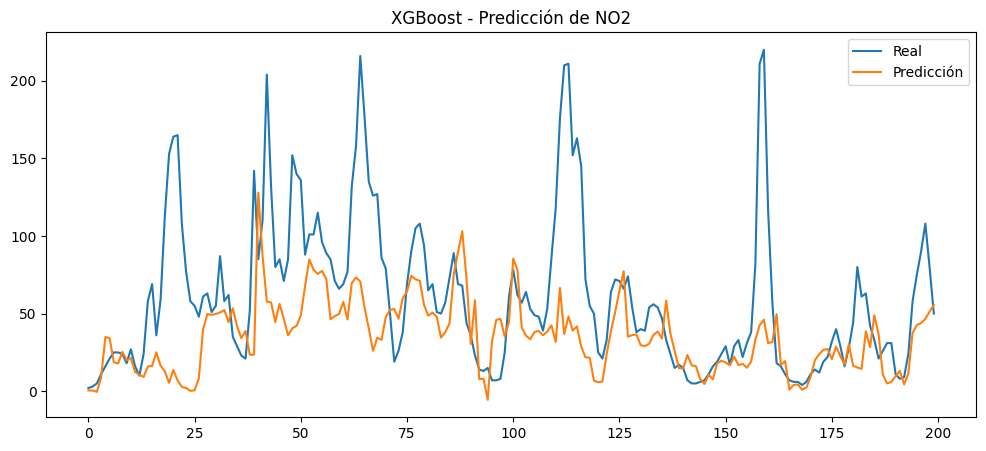

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:200], label="Real")
plt.plot(y_pred[:200], label="Predicción")
plt.legend()
plt.title("XGBoost - Predicción de NO2")
plt.show()

El modelo captura correctamente la tendencia general, aunque presenta dificultades para predecir picos extremos de contaminación.

### ***Importancia de las variables***

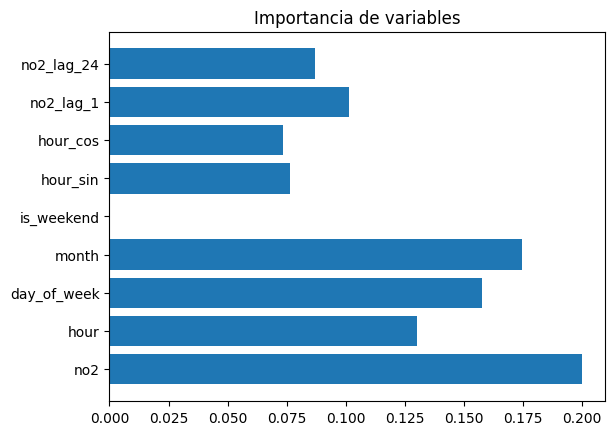

In [27]:
importances = model.feature_importances_

plt.barh(X_train.columns, importances)
plt.title("Importancia de variables")
plt.show()

**Interpretación**:
- El modelo muestra que las variables más relevantes son:
    - **no2** -> valor actual de la contaminación.
    - **day_of_week** -> día de la semana.
    - **month** -> estacionalidad mensual.
    - **hour** -> hora del día
- También destacan:
    - no2_lag_1 y no2_lag_24 -> dependencia temporal.
    - hour_sin / hour_cos -> patrón cíclico diario.

**Conclusión**:
- Se apoya fuertemente en la estructura temporal y utiliza tanto el pasado (lags) como el contexto temporal.

### ***Shap***

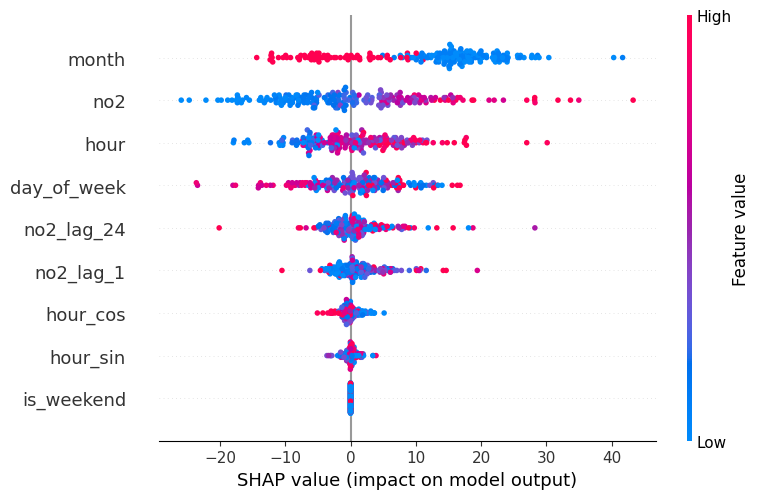

In [ ]:
X_sample = X_test.sample(200, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

**Interpretación**:
- Este gráfico muestra cómo influyen las variables en la predicción del modelo.
- Cada punto representa una observación, es decir, una hora, y el color indica si el valor de la variable es alto o bajo.
- En el eje horizontal vemos el impacto: hacia la derecha aumenta la predicción de NO2 y hacia la izquierda la reduce.
- Observamos que variables como el mes y los valores pasados de NO2 tienen mayor influencia, lo que indica que el modelo captura patrones estacionales y la dependencia temporal.
- En cambio, variables como si es fin de semana tienen menor impacto.

**Conclusión:**
- En conjunto, el modelo utiliza principalmente la información temporal y los valores pasados para realizar la predicción.

In [38]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

X = df[features]
y = df["target"]

tscv = TimeSeriesSplit(n_splits=5)

results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    model_cv = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    )

    model_cv.fit(X_train_cv, y_train_cv)

    y_pred_cv = model_cv.predict(X_test_cv)

    mae = mean_absolute_error(y_test_cv, y_pred_cv)
    rmse = np.sqrt(mean_squared_error(y_test_cv, y_pred_cv))

    results.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse
    })

walk_forward_results = pd.DataFrame(results)
walk_forward_results

,fold,MAE,RMSE
0,1,18.400797,25.903867
1,2,12.238575,19.291692
2,3,14.321762,25.972183
3,4,26.916610,45.616771
4,5,31.938857,45.143025


In [39]:
print("MAE medio:", walk_forward_results["MAE"].mean())
print("RMSE medio:", walk_forward_results["RMSE"].mean())

MAE medio: 20.763320172896258
RMSE medio: 32.385507511830504


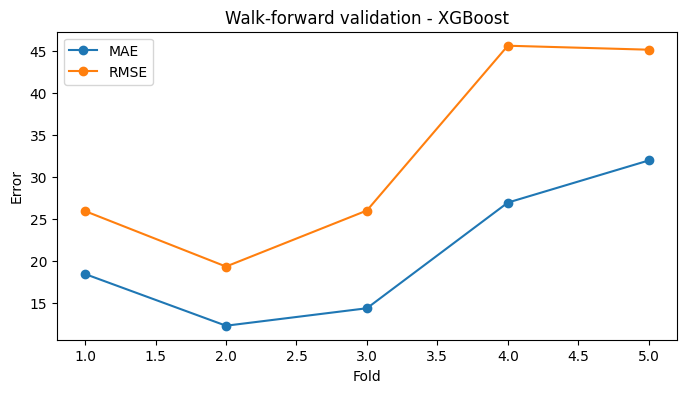

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(walk_forward_results["fold"], walk_forward_results["MAE"], marker="o", label="MAE")
plt.plot(walk_forward_results["fold"], walk_forward_results["RMSE"], marker="o", label="RMSE")
plt.xlabel("Fold")
plt.ylabel("Error")
plt.title("Walk-forward validation - XGBoost")
plt.legend()
plt.show()

## Optimización de hiperparámetros con Optuna

Se ha utilizado Optuna para optimizar automáticamente los hiperparámetros
del modelo XGBoost, buscando la combinación que minimiza el error de predicción.

In [41]:
! pip install optuna

In [42]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

def objective(trial):
    model = XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    return mae

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

print("Mejores hiperparámetros:")
print(study.best_params)

[I 2026-05-01 14:38:35,582] A new study created in memory with name: no-name-bd1be7b6-c6bc-4aad-86d1-4891201bf0d7
[I 2026-05-01 14:38:36,341] Trial 0 finished with value: 34.223501260477626 and parameters: {'n_estimators': 91, 'max_depth': 7, 'learning_rate': 0.2669350830331264, 'subsample': 0.7430313698822012, 'colsample_bytree': 0.9931367414072791}. Best is trial 0 with value: 34.223501260477626.
[I 2026-05-01 14:38:36,490] Trial 1 finished with value: 32.28221060711706 and parameters: {'n_estimators': 265, 'max_depth': 3, 'learning_rate': 0.22562707746823163, 'subsample': 0.9598943896963471, 'colsample_bytree': 0.7885033306060003}. Best is trial 1 with value: 32.28221060711706.
[I 2026-05-01 14:38:36,674] Trial 2 finished with value: 30.793134363249816 and parameters: {'n_estimators': 52, 'max_depth': 8, 'learning_rate': 0.08112794753622322, 'subsample': 0.7515025481017261, 'colsample_bytree': 0.926787401543774}. Best is trial 2 with value: 30.793134363249816.
[I 2026-05-01 14:38:36

Mejores hiperparámetros:
{'n_estimators': 98, 'max_depth': 5, 'learning_rate': 0.10005547826671582, 'subsample': 0.9884870112743809, 'colsample_bytree': 0.7823501124625927}


Entrnar

In [43]:
best_params = study.best_params

model_opt = XGBRegressor(**best_params, random_state=42)
model_opt.fit(X_train, y_train)

y_pred_opt = model_opt.predict(X_test)

Evaluar

In [44]:
mae_opt = mean_absolute_error(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))

print("MAE optimizado:", mae_opt)
print("RMSE optimizado:", rmse_opt)

MAE optimizado: 29.902940266538764
RMSE optimizado: 42.86843212685129


## **LSTM**

### ***Escalar datos***

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# SOLO TRAIN
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# TEST SOLO TRANSFORM
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

### ***Creación de secuencias***

In [30]:
def create_sequences(X, y, time_steps=24):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

In [31]:
model_lstm = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(50),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")

### ***Modelo LSTM***

In [32]:
model_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)

Epoch 1/10
250/250 [==============================] - 4s 12ms/step - loss: 0.0051 - val_loss: 0.0024
Epoch 2/10
250/250 [==============================] - 3s 11ms/step - loss: 0.0019 - val_loss: 0.0025
Epoch 3/10
250/250 [==============================] - 3s 11ms/step - loss: 0.0018 - val_loss: 0.0023
Epoch 4/10
250/250 [==============================] - 2s 9ms/step - loss: 0.0018 - val_loss: 0.0024
Epoch 5/10
250/250 [==============================] - 2s 9ms/step - loss: 0.0017 - val_loss: 0.0022
Epoch 6/10
250/250 [==============================] - 2s 9ms/step - loss: 0.0017 - val_loss: 0.0029
Epoch 7/10
250/250 [==============================] - 2s 9ms/step - loss: 0.0017 - val_loss: 0.0026
Epoch 8/10
250/250 [==============================] - 2s 9ms/step - loss: 0.0017 - val_loss: 0.0026
Epoch 9/10
250/250 [==============================] - 2s 8ms/step - loss: 0.0017 - val_loss: 0.0024
Epoch 10/10
250/250 [==============================] - 2s 8ms/step - loss: 0.0017 - val_loss: 0.0

### ***Predicción***

In [33]:
y_pred_lstm = model_lstm.predict(X_test_seq)

62/62 [==============================] - 1s 3ms/step


### ***Desescalar***

In [34]:
y_test_real = scaler_y.inverse_transform(y_test_seq)
y_pred_real = scaler_y.inverse_transform(y_pred_lstm)

In [35]:
mae_lstm = mean_absolute_error(y_test_real, y_pred_real)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print("MAE LSTM:", mae_lstm)
print("RMSE LSTM:", rmse_lstm)

MAE LSTM: 24.781272366952294
RMSE LSTM: 39.42515340699679


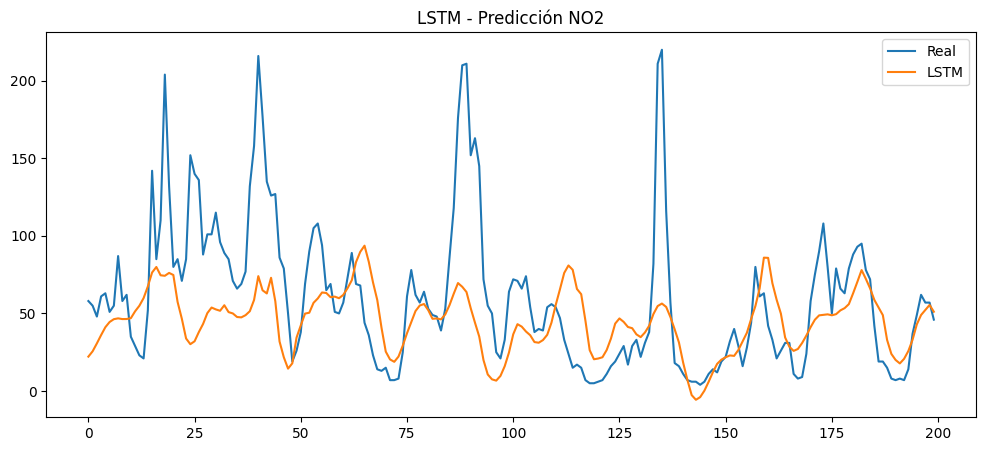

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test_real[:200], label="Real")
plt.plot(y_pred_real[:200], label="LSTM")
plt.legend()
plt.title("LSTM - Predicción NO2")
plt.show()

El modelo LSTM captura la tendencia general de la serie, pero presenta dificultades para predecir picos de contaminación, mostrando un comportamiento más suavizado en comparación con XGBoost.

Para XGBoost se ha aplicado SHAP para interpretar el modelo, mientras que para LSTM se ha realizado un análisis basado en su rendimiento y comportamiento, ya que la interpretabilidad en modelos secuenciales es más compleja.

## **Semana3**

### ***Guardar el modelo XGBoost***

In [37]:
import joblib

joblib.dump(model, "../models/xgboost_no2.pkl")
joblib.dump(features, "../models/features.pkl")

['../models/features.pkl']

### ***FastAPI***

In [ ]:
# pip install uvicorn fastapi

### ***Streamlit***

In [ ]:
# ! pip install streamlit requests

## Objetivo
En esta fase del proyecto hemos desarrollado un sistema completo que permite:

- Realizar predicciones de NO₂ a 24 horas
- Exponer el modelo mediante una API (FastAPI)
- Crear una interfaz visual interactiva (Streamlit)

---

## Arquitectura del sistema

El flujo del sistema es el siguiente:


Usuario → Streamlit → API FastAPI → Modelo XGBoost → Predicción → Interfaz

## 1. API con FastAPI

Se ha desarrollado una API que permite enviar datos y obtener predicciones en tiempo real.

### Endpoint principal

POST /predict


### Ejemplo de entrada
{
  "no2": 50,
  "hour": 12,
  "day_of_week": 2,
  "month": 1,
  "is_weekend": 0,
  "hour_sin": 0,
  "hour_cos": -1,
  "no2_lag_1": 45,
  "no2_lag_24": 55
}

Ejemplo de salida
{
  "prediction_no2_24h": 64.31,
  "alert": "Normal"
}

## 2. Interfaz web con Streamlit
Se ha creado una aplicación web donde el usuario puede:
- Introducir datos actuales de NO₂
- Seleccionar variables temporales (hora, día, mes)
- Obtener una predicción en tiempo real
- Visualizar la evolución de la contaminación
- Recibir una alerta visual (verde, amarillo o rojo)

### Interpretación de resultados

La aplicación muestra:

- NO₂ actual
- Predicción a 24h
- Variación estimada
- Gráfico de evolución (pasado → presente → futuro)

Ejemplo
- NO₂ actual: 50
- Predicción: 64.31
- Variación: +14.31

### Interpretación:
El modelo predice un aumento de la contaminación en las próximas 24 horas.

## 3. Cómo ejecutar el proyecto 
- Lanzar la API
  - python -m uvicorn app.api.main:app --reload
  - http://127.0.0.1:8000/docs
- Lanzar la aplicación web
  - streamlit run app/streamlit/app.py
  - http://localhost:8501


### ***Test de integración***

In [ ]:
import requests

def test_predict():
    payload = {
        "no2": 50,
        "hour": 12,
        "day_of_week": 2,
        "month": 1,
        "is_weekend": 0,
        "hour_sin": 0,
        "hour_cos": -1,
        "no2_lag_1": 45,
        "no2_lag_24": 55
    }

    response = requests.post("http://127.0.0.1:8000/predict", json=payload)

    print(response.status_code)
    print(response.json())

    assert response.status_code == 200


test_predict()

200
{'prediction_no2_24h': 64.31306457519531, 'alert': 'Normal'}


Hemos implementado un test de integración que envía una petición real a la API
con datos de ejemplo.

El objetivo es comprobar que el sistema completo funciona correctamente,
es decir, que la API recibe los datos, el modelo hace la predicción
y devuelve una respuesta válida.

Si todo funciona bien, el test no muestra ningún error.
Si algo falla, aparece un error automáticamente.